# Spam Message Detection using NLP

This notebook implements a simple **Spam vs Ham message classifier** using:
- text preprocessing
- TF-IDF vectorization
- Logistic Regression

It is ready to run in **Google Colab**.


In [1]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ================================
# Load Dataset from Google Drive
# ================================

file_path = '/content/drive/MyDrive/spam.csv'
df = pd.read_csv(file_path, encoding='latin-1')
if 'v1' in df.columns and 'v2' in df.columns:
    df = df[['v1', 'v2']]
    df.columns = ['label', 'message']
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
print("First 5 rows:")
print(df.head())
print("\nDataset shape:", df.shape)
print("\nColumn names:", df.columns)
print("\nClass distribution:")
print(df['label'].value_counts())

First 5 rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Dataset shape: (5572, 2)

Column names: Index(['label', 'message'], dtype='object')

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [4]:
# ================================
# Text Preprocessing (Full Safe Version)
# ================================

nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
# Preprocessing function
def preprocess_text(text):
    if pd.isna(text):   # handle missing values
        return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)   # remove URLs
    text = re.sub(r'\d+', '', text)                       # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)
# Apply preprocessing
df['clean_message'] = df['message'].apply(preprocess_text)
# Display results
print("Sample cleaned data:\n")
print(df[['message', 'clean_message']].head())

Sample cleaned data:

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                       clean_message  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry wkly comp win fa cup final tkts st ...  
3                u dun say early hor u c already say  
4        nah dont think goes usf lives around though  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
# Convert labels to numeric
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_message'],
    df['label_num'],
    test_size=0.2,
    random_state=42,
    stratify=df['label_num']
)
# TF-IDF feature extraction
vectorizer = TfidfVectorizer(max_features=3000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

Training data shape: (4457, 3000)
Testing data shape: (1115, 3000)


In [6]:
# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# Prediction
y_pred = model.predict(X_test_tfidf)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Real', 'Spam']))

Accuracy: 96.68 %

Classification Report:

              precision    recall  f1-score   support

        Real       0.96      1.00      0.98       966
        Spam       0.98      0.77      0.86       149

    accuracy                           0.97      1115
   macro avg       0.97      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



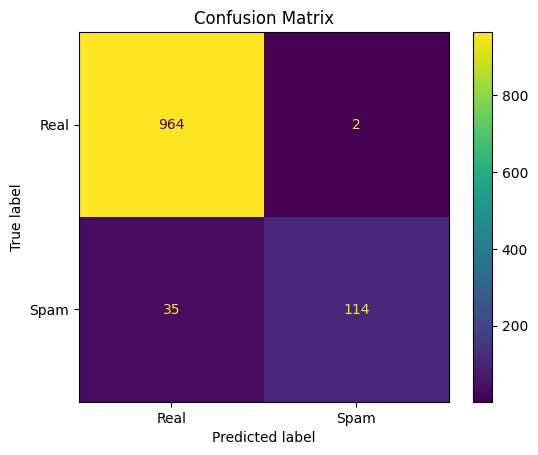

In [7]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Spam'])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [8]:
# Testing custom messages
def predict_message(message):
    cleaned = preprocess_text(message)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    return "Spam" if prediction == 1 else "Normal"

test_messages = [
    "Congratulations! You have won a free vacation. Call now!",
    "Hey, are you coming to class today?",
    "Limited time offer! Claim your prize now.",
    "Can you send me the notes after class?"
]

for msg in test_messages:
    print("Message:", msg)
    print("Prediction:", predict_message(msg))
    print("-" * 50)

Message: Congratulations! You have won a free vacation. Call now!
Prediction: Spam
--------------------------------------------------
Message: Hey, are you coming to class today?
Prediction: Normal
--------------------------------------------------
Message: Limited time offer! Claim your prize now.
Prediction: Spam
--------------------------------------------------
Message: Can you send me the notes after class?
Prediction: Normal
--------------------------------------------------


In [9]:
# Try your own message here
custom_input = "You have been selected for a cash prize. Click the link now!"
print("Custom message prediction:", predict_message(custom_input))

Custom message prediction: Spam
